# IMPORT IMPORTANT LIBRARIES

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.metrics import classification_report 
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/saitejabandaruin/automated-pipeline-dataset-output/global_tech_startups_2026.csv


# LOADING DATASET

In [2]:
df=pd.read_csv("/kaggle/input/datasets/saitejabandaruin/automated-pipeline-dataset-output/global_tech_startups_2026.csv")

# STATISTICAL ANALYSIS

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  object 
 1   Domain                      25000 non-null  object 
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  object 
 4   City                        25000 non-null  object 
 5   Funding_Stage               25000 non-null  object 
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      250

In [4]:
df.shape

(25000, 17)

In [5]:
df.describe()

,Founding_Year,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,2018.917400,59.631098,464.100121,33.300890,3.168847,12.189032,211.739920,31.563320,180.176600
std,2.811963,208.725699,1777.909318,139.243809,10.877553,10.099990,693.946443,175.987811,606.174385
min,2012.000000,0.000000,1.030000,0.050000,0.060000,0.000000,5.000000,0.000000,0.000000
25%,2017.000000,2.050000,28.997500,1.800000,0.430000,3.900000,30.000000,0.000000,22.000000
50%,2019.000000,8.465000,71.775000,4.825000,0.720000,10.600000,48.000000,0.000000,42.000000
75%,2021.000000,36.100000,267.795000,17.972500,2.240000,17.500000,154.000000,16.000000,119.000000
max,2025.000000,7867.390000,91692.420000,9021.530000,515.760000,89.600000,30086.000000,10280.000000,25657.000000


In [6]:
df.nunique()

Company_ID                    24999
Domain                           10
Founding_Year                    14
Country                          10
City                             29
Funding_Stage                     6
Total_Funding_USD_Millions     8473
Valuation_USD_Millions        16439
Revenue_ARR_Millions           6457
Monthly_Burn_Rate_Millions     2142
Runway_Months_2024              596
Peak_Headcount_2023            1748
Layoffs_2024_2025               641
Current_Headcount_2026         1616
Investor_Tier                     5
AI_Adoption_Level                 3
Acquisition_Status                5
dtype: int64

## duplicate detection

In [7]:
df.duplicated().sum()

np.int64(0)

## null detection

In [8]:
df.isnull().sum()

Company_ID                       0
Domain                           0
Founding_Year                    0
Country                          0
City                             0
Funding_Stage                    0
Total_Funding_USD_Millions       0
Valuation_USD_Millions           0
Revenue_ARR_Millions             0
Monthly_Burn_Rate_Millions       0
Runway_Months_2024               0
Peak_Headcount_2023              0
Layoffs_2024_2025                0
Current_Headcount_2026           0
Investor_Tier                    0
AI_Adoption_Level             2592
Acquisition_Status               0
dtype: int64

## HANDLING NULL VALUES

In [9]:
col='AI_Adoption_Level'
df[col]=df[col].fillna(df[col].mode()[0])

# dropping unnecessary column

In [10]:
df=df.drop(columns='Company_ID')

# EDA

## DISTRIBUTION OF IMPORTANT COLUMNS

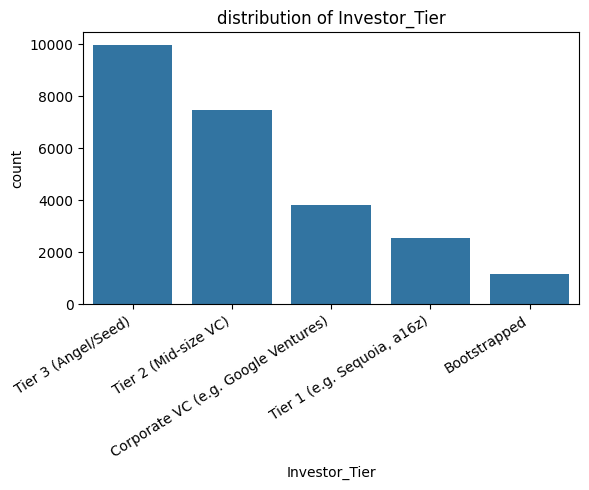

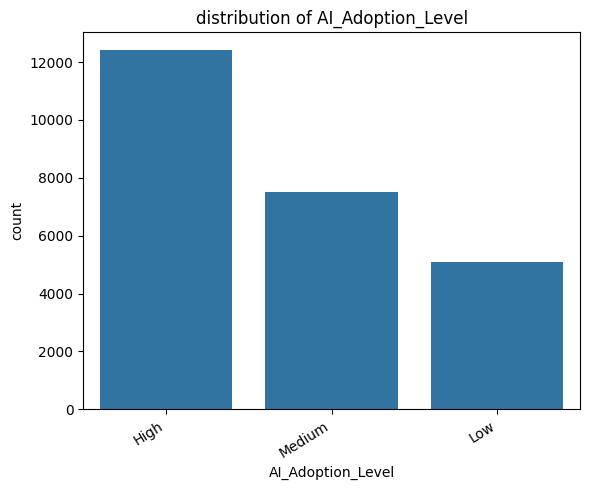

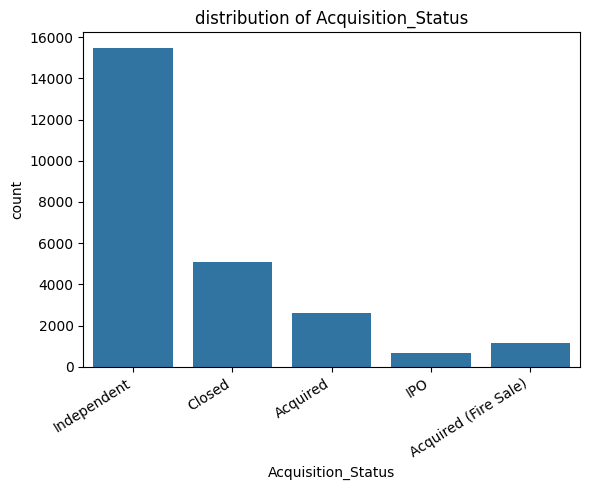

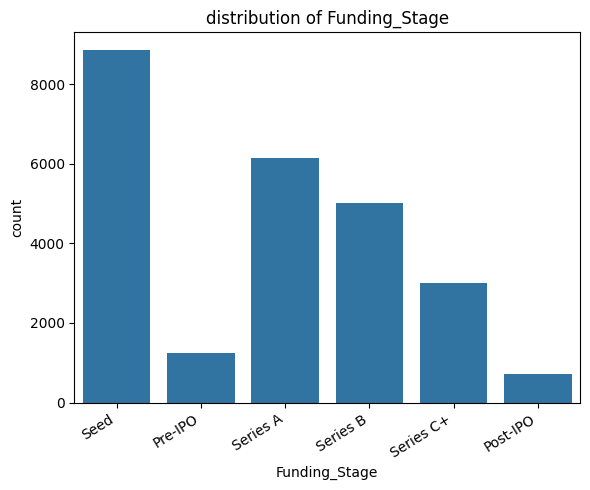

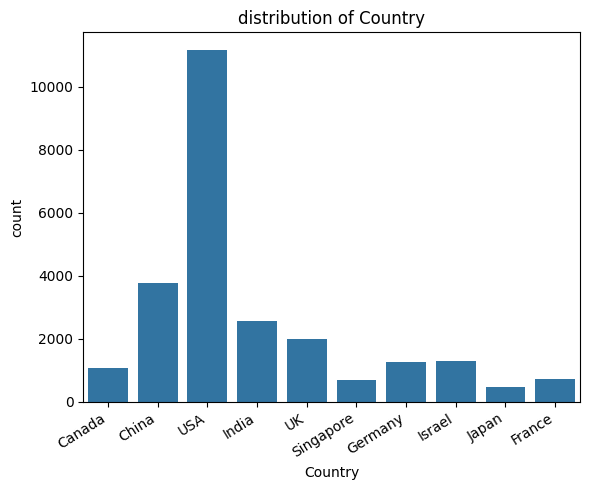

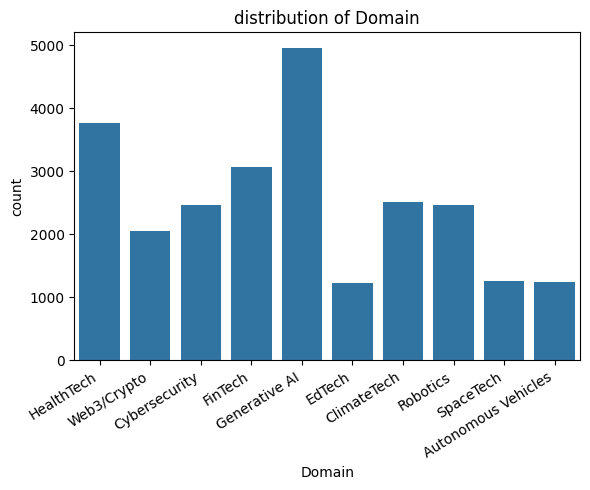

In [11]:
list_one=['Investor_Tier','AI_Adoption_Level','Acquisition_Status','Funding_Stage','Country','Domain']
for c in list_one:
    plt.figure(figsize=(6,5))
    sns.countplot(data=df,x=c)
    plt.title(f"distribution of {c}")
    plt.xticks(rotation=32,ha="right")
    plt.tight_layout()
    plt.show()
    print("\n\n")

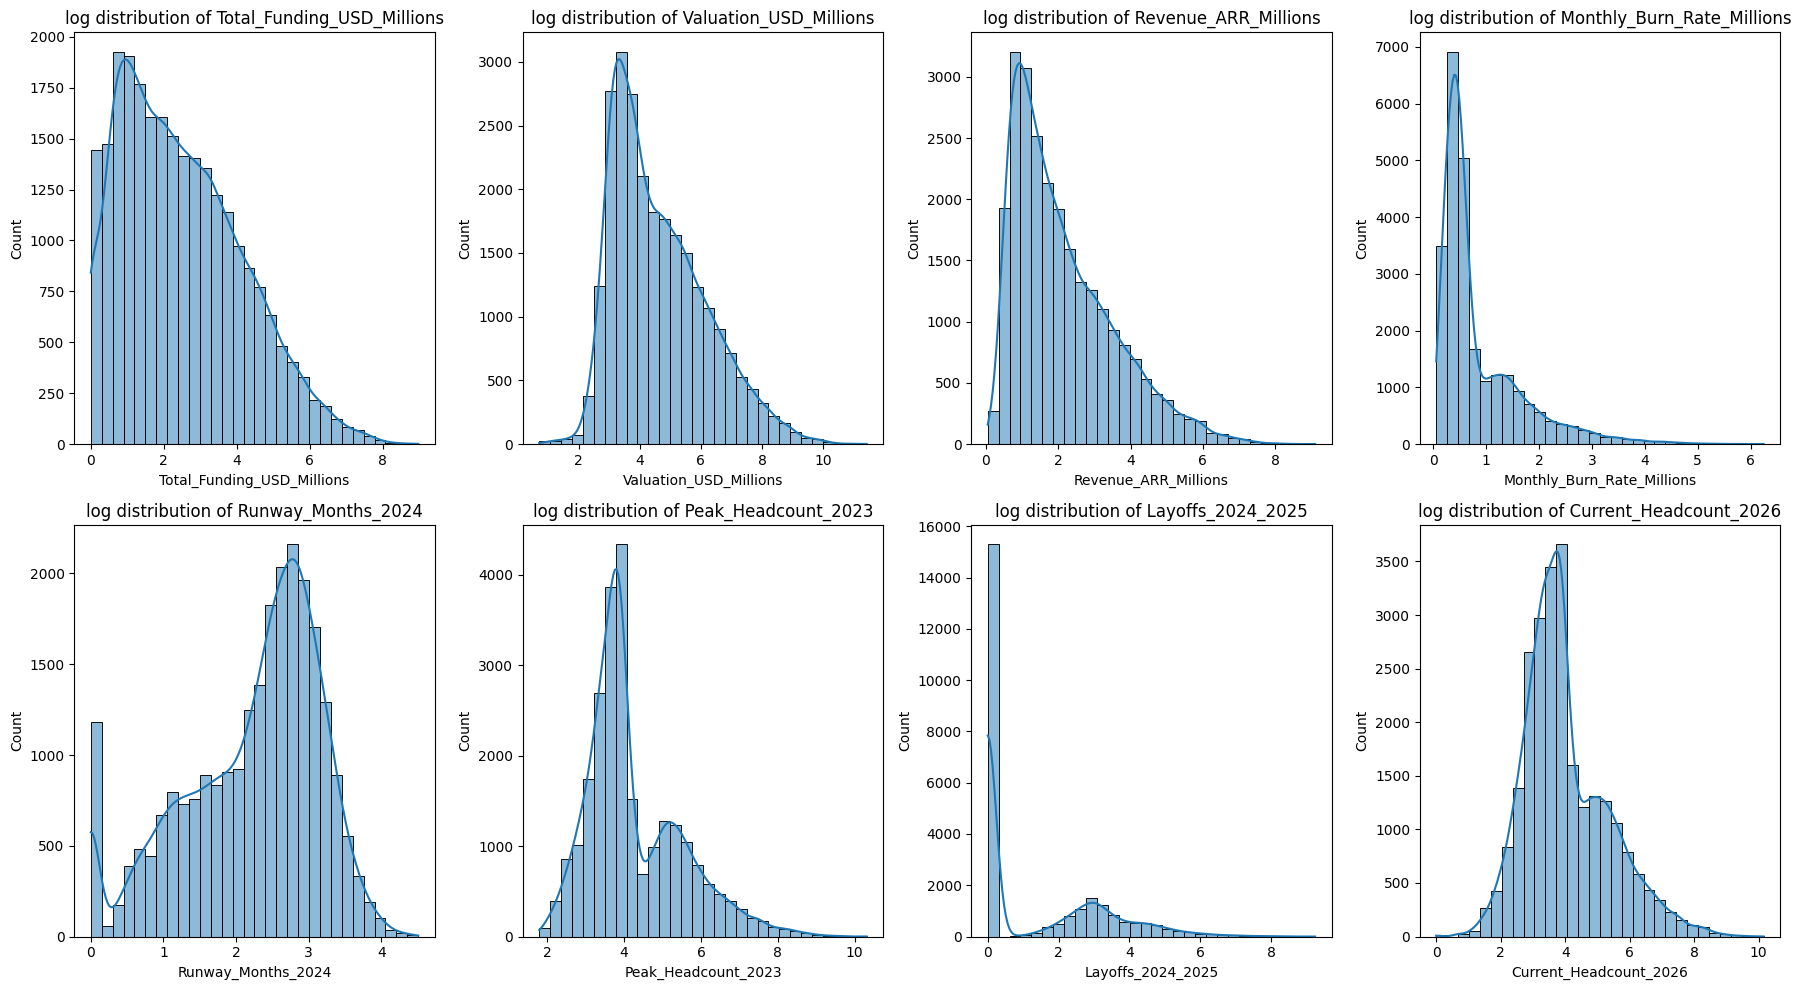

In [12]:
list_two=['Total_Funding_USD_Millions','Valuation_USD_Millions','Revenue_ARR_Millions','Monthly_Burn_Rate_Millions','Runway_Months_2024','Peak_Headcount_2023','Layoffs_2024_2025'
,'Current_Headcount_2026']

fig,axes=plt.subplots(2,4,figsize=(18,10))
axes=axes.ravel()

for i,c in enumerate(list_two):
    ax=axes[i]
    sns.histplot(np.log1p(df[c]),bins=30,kde=True,ax=ax)
    ax.set_title(f'log distribution of {c}')

plt.tight_layout()
plt.show()

## IMPACT ON MY TARGET COLUMN BY NUMERIC COLUMNS

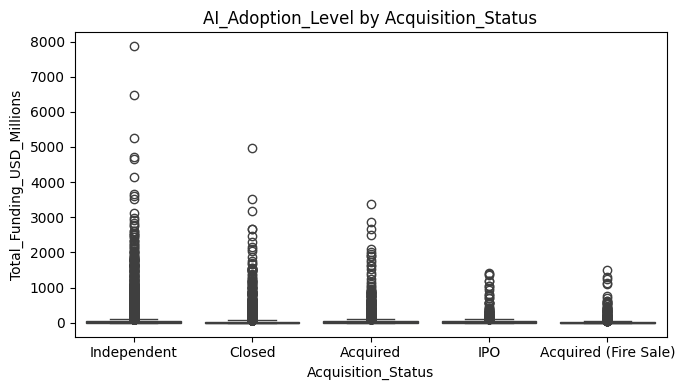

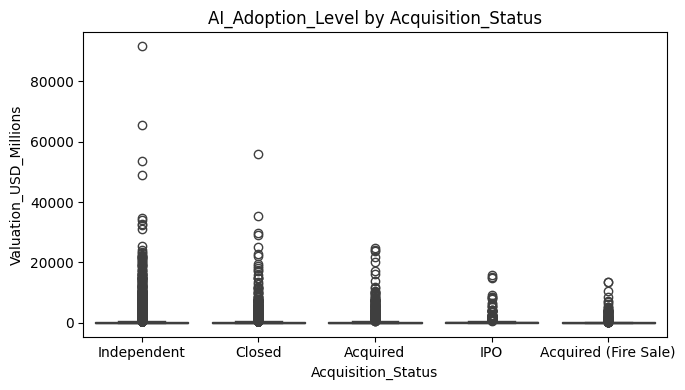

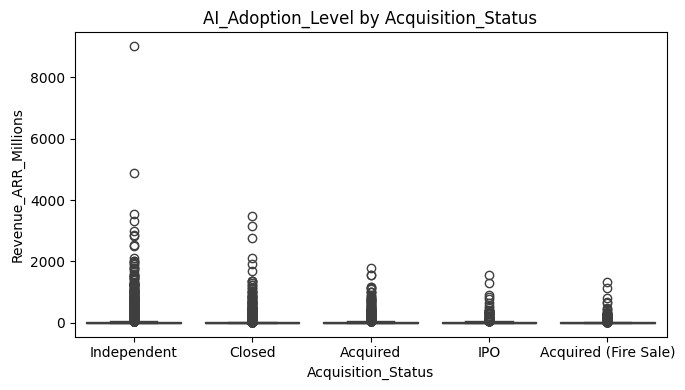

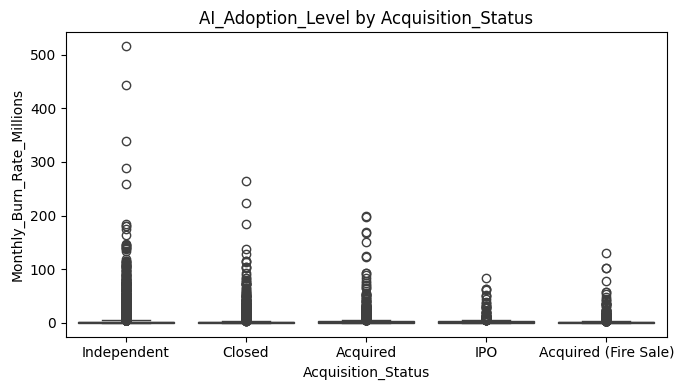

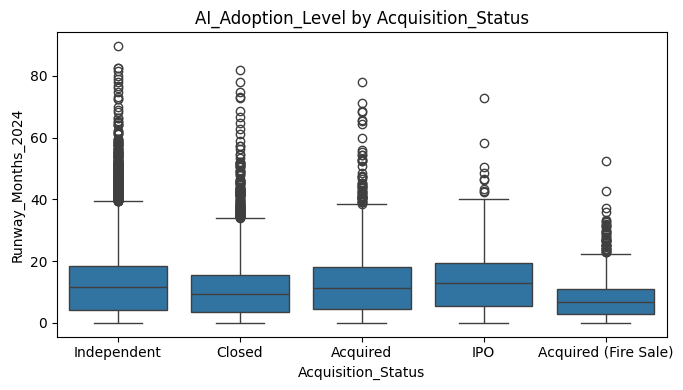

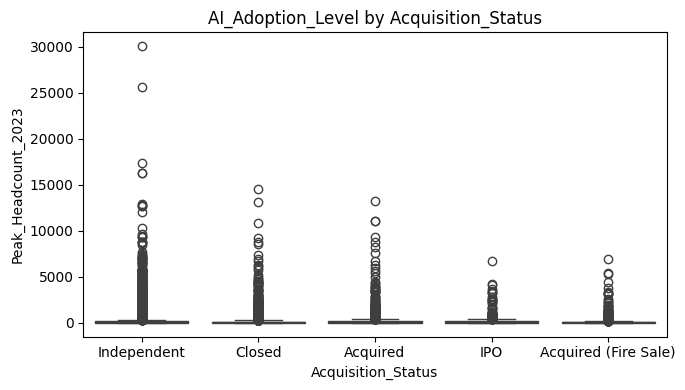

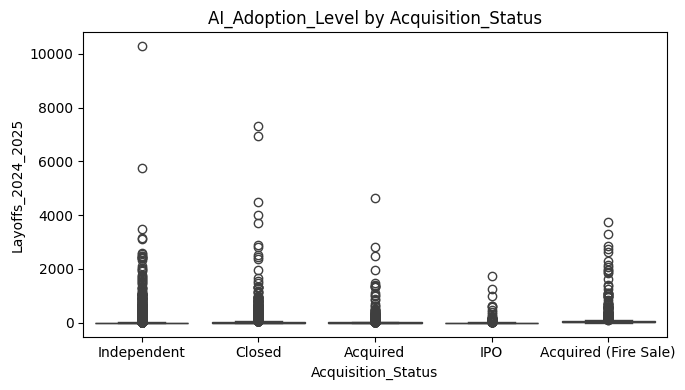

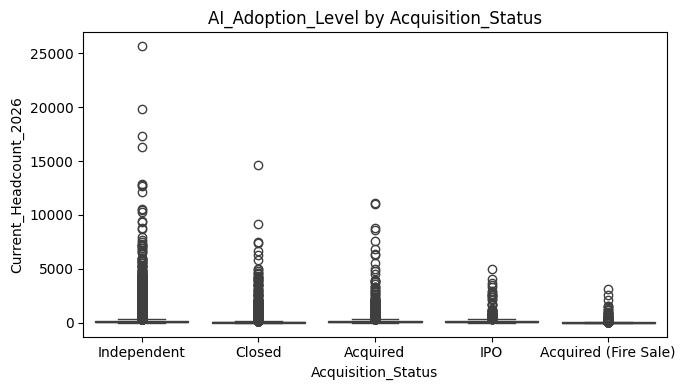

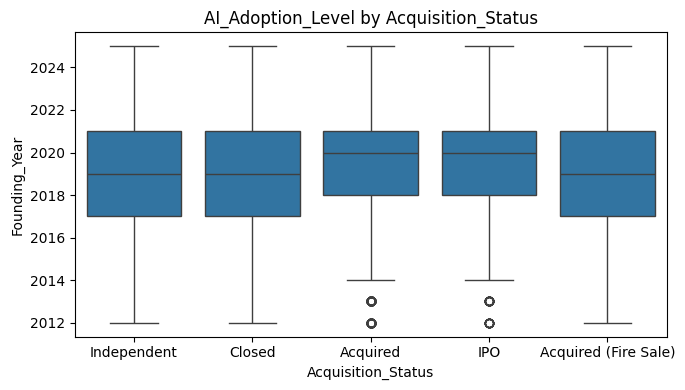

In [13]:
list_three=['Total_Funding_USD_Millions','Valuation_USD_Millions','Revenue_ARR_Millions','Monthly_Burn_Rate_Millions','Runway_Months_2024','Peak_Headcount_2023','Layoffs_2024_2025'
,'Current_Headcount_2026','Founding_Year']

trgt='Acquisition_Status'

for c in list_three:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=trgt,y=c,data=df)
    plt.title(f'{col} by {trgt}')
    plt.tight_layout()
    plt.show()

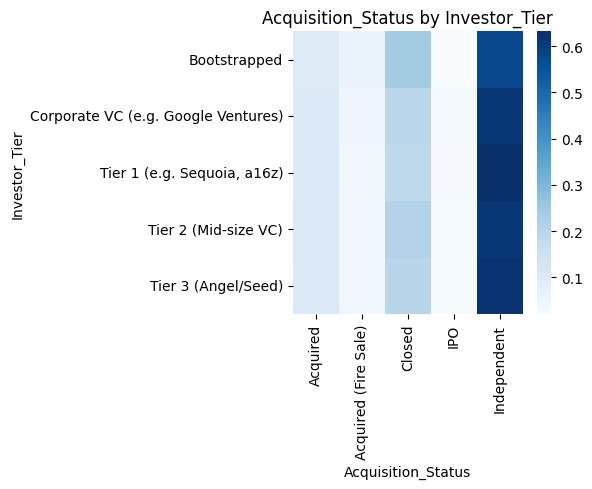

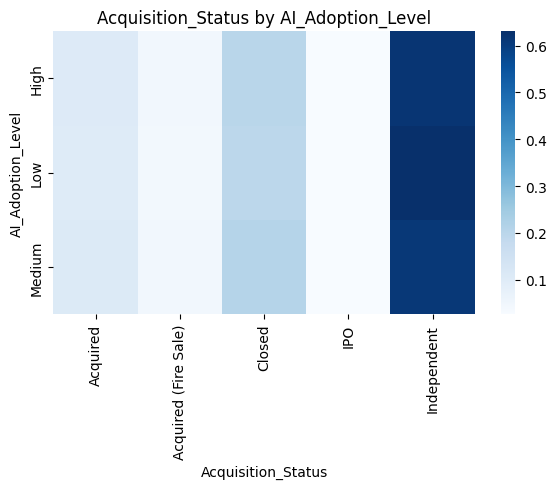

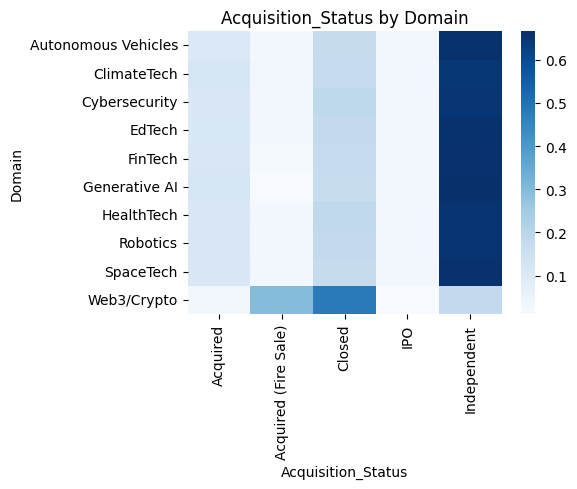

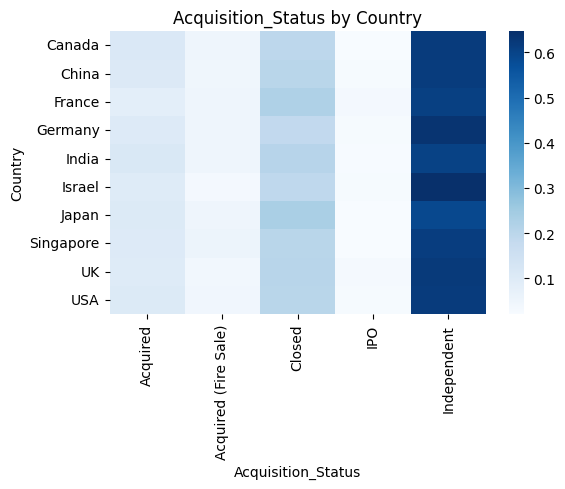

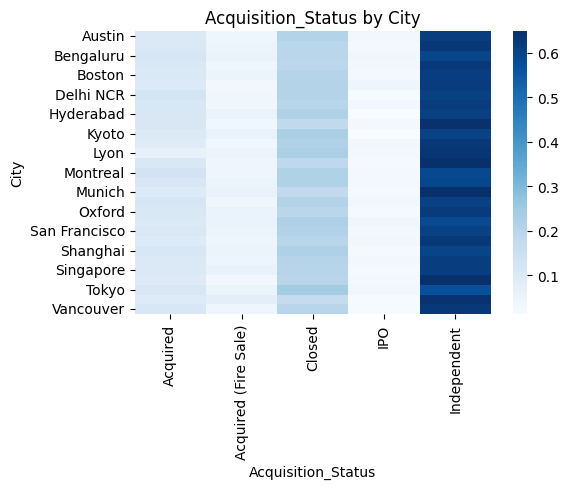

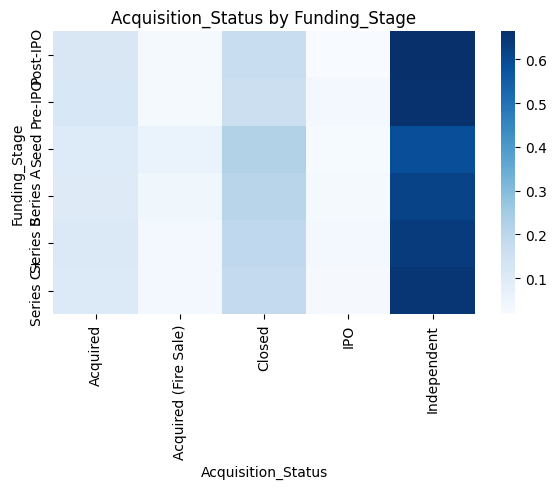

In [14]:

    

list_four=['Investor_Tier','AI_Adoption_Level','Domain','Country','City','Funding_Stage']

for col in list_four:
    ct=pd.crosstab(df[col],df[trgt],normalize="index")
    plt.figure(figsize=(6,5))
    sns.heatmap(ct,cmap="Blues",cbar=True)
    plt.title(f"{trgt} by {col}")
    plt.tight_layout()
    plt.show()

    


# SPLITING THE DATASET

In [15]:
trgt='Acquisition_Status'
X=df.drop(columns=['Acquisition_Status'])
y=df['Acquisition_Status']
cat_col=X.columns.tolist()

le=LabelEncoder()
y_enc=le.fit_transform(y)
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y_enc
)



# ENCODING AND MODEL TRAINING

In [16]:

preprocess=ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_col)
    ]
)

##model=LogisticRegression(max_iter=2000,class_weight="balanced")
lgbm=LGBMClassifier(
    objective="multiclass",
    num_class="NUM_CLASS",
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42
    
)
cl=Pipeline(steps=[("prep",preprocess),("model",lgbm)])
cl.fit(X_train,y_train)

pred=cl.predict(X_test)




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2474
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 1237
[LightGBM] [Info] Start training from score -2.249518
[LightGBM] [Info] Start training from score -3.085657
[LightGBM] [Info] Start training from score -1.592335
[LightGBM] [Info] Start training from score -3.606378
[LightGBM] [Info] Start training from score -0.480862


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# EVALUATION

In [17]:
print(classification_report(y_test,pred))

                      precision    recall  f1-score   support

            Acquired       0.06      0.01      0.01       527
Acquired (Fire Sale)       0.40      0.21      0.28       228
              Closed       0.43      0.25      0.31      1018
                 IPO       0.11      0.01      0.01       136
         Independent       0.68      0.93      0.79      3091

            accuracy                           0.64      5000
           macro avg       0.34      0.28      0.28      5000
        weighted avg       0.54      0.64      0.56      5000

